Import and Configure GPU Memory Growth

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Set this before importing libraries

import torch
print(torch.cuda.is_available())
print(torch.cuda.current_device())
print("CUDA available:", torch.cuda.is_available())
print("cuDNN enabled:", torch.backends.cudnn.enabled)
print("cuDNN version:", torch.backends.cudnn.version())


True
0
CUDA available: True
cuDNN enabled: True
cuDNN version: 90100


Load DataFrames and PreProcess

In [2]:
import os
import pandas as pd

# Load all CSV files from "etfs" and "stocks" directories
data_dir_etfs = './data/etfs'
data_dir_stocks = './data/stocks'

all_files = []
for directory in [data_dir_stocks, data_dir_etfs]:
    for file in os.listdir(directory):
        if file.endswith('.csv'):
            all_files.append(os.path.join(directory, file))

# Concatenate all data into a single DataFrame
data_list = []
for file in all_files:
    df = pd.read_csv(file)
    data_list.append(df)

data = pd.concat(data_list)

# Display the first few rows of the concatenated DataFrame
print("First few rows of the combined data:")
print(data.head())

# Check for missing values
print("Checking for missing values in each column:")
print(data.isnull().sum())

# Drop rows with missing values
data = data.dropna()

# Display the shape of the cleaned data
print("Shape of the cleaned data:", data.shape)

# Display the first few rows of the cleaned data
print("First few rows of the cleaned data:")
print(data.head())


First few rows of the combined data:
         Date       Open       High        Low      Close  Adj Close  \
0  1999-11-18  32.546494  35.765381  28.612303  31.473534  27.068665   
1  1999-11-19  30.713520  30.758226  28.478184  28.880543  24.838577   
2  1999-11-22  29.551144  31.473534  28.657009  31.473534  27.068665   
3  1999-11-23  30.400572  31.205294  28.612303  28.612303  24.607880   
4  1999-11-24  28.701717  29.998211  28.612303  29.372318  25.261524   

       Volume  
0  62546300.0  
1  15234100.0  
2   6577800.0  
3   5975600.0  
4   4843200.0  
Checking for missing values in each column:
Date           0
Open         683
High         683
Low          683
Close        683
Adj Close    683
Volume       683
dtype: int64
Shape of the cleaned data: (28147685, 7)
First few rows of the cleaned data:
         Date       Open       High        Low      Close  Adj Close  \
0  1999-11-18  32.546494  35.765381  28.612303  31.473534  27.068665   
1  1999-11-19  30.713520  30.758226  

PreProcessing

In [3]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Convert 'Date' column to datetime and set as index
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Check for NaN and infinity values
print("Checking for NaN values in data:", np.isnan(scaled_data).any())
print("Checking for infinity values in data:", np.isinf(scaled_data).any())

# Split the data into training and testing sets
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Prepare the input and output for the model
def create_dataset(dataset, look_back=1):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        y.append(dataset[i + look_back, :])
    return np.array(X), np.array(y)

look_back = 20
X_train, y_train = create_dataset(train_data, look_back)
X_test, y_test = create_dataset(test_data, look_back)

# Display shapes of the datasets
print("Shapes of datasets:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Checking for NaN values in data: False
Checking for infinity values in data: False
Shapes of datasets:
X_train: (22518128, 20, 6)
y_train: (22518128, 6)
X_test: (5629517, 20, 6)
y_test: (5629517, 6)


Build and Train

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from tqdm import tqdm  # Import tqdm for progress bars

# Set device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Prepare the Data ---
# Assuming X_train, y_train, X_test, y_test are already defined as NumPy arrays.
# X_train shape: (num_samples, look_back, num_features)
# y_train shape: (num_samples, num_features) -- matching the Keras output layer

# Convert numpy arrays to torch tensors (float type)
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

# Create DataLoaders for training and validation/test sets
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

# --- Define the Model ---
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        # First LSTM layer: return sequences
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=256, num_layers=1, batch_first=True)
        self.dropout1 = nn.Dropout(0.3)
        # Second LSTM layer: return only final output (return_sequences=False equivalent)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, num_layers=1, batch_first=True)
        self.dropout2 = nn.Dropout(0.3)
        # Dense output layer: same number of units as the number of features
        self.fc = nn.Linear(256, output_size)
        
    def forward(self, x):
        # x shape: (batch_size, look_back, input_size)
        out, _ = self.lstm1(x)           # out shape: (batch_size, look_back, 150)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)         # out shape: (batch_size, look_back, 150)
        # Take the output at the final timestep
        out = out[:, -1, :]              # shape: (batch_size, 150)
        out = self.dropout2(out)
        out = self.fc(out)               # shape: (batch_size, output_size)
        return out

# Set parameters based on your data
look_back = X_train.shape[1]          # number of timesteps
input_size = X_train.shape[2]         # number of features
output_size = X_train.shape[2]        # same as number of features

# Instantiate the model, define the loss and optimizer
model = LSTMModel(input_size=input_size, hidden_size=256, output_size=output_size)
model = model.to(device)  # move model to GPU if available

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Regularization hyperparameters
l1_lambda = 1e-10  # adjust as needed
l2_lambda = 7e-10  # adjust as needed

# Global variables for tracking best epoch (best validation loss)
best_val_loss = float('inf')
best_epoch = -1

# --- Training Loop ---
num_epochs = 15  # (Update as needed)
patience_batches = 20000
for epoch in range(num_epochs):
    best_batch_loss = float('inf')
    no_improve_count = 0
    model.train()
    running_loss = 0.0
    # Training progress bar for the current epoch with white color
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training", leave=False, colour='white')
    for batch_x, batch_y in train_bar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)  # move batch data to device
        optimizer.zero_grad()
        
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        # Compute L1 norm over all model parameters (L2 omitted here for brevity, but can be added similarly)
        l1_norm = sum(param.abs().sum() for param in model.parameters())
        l2_norm = sum(param.pow(2).sum() for param in model.parameters())
        loss = loss + l2_lambda * l2_norm
        loss.backward()
        optimizer.step()
        
        batch_loss = loss.item()
        
        running_loss += loss.item() * batch_x.size(0)
        train_bar.set_postfix(loss=loss.item())
        
        # Early stopping based on batch loss
        
        if batch_loss < best_batch_loss:
            best_batch_loss = batch_loss
            no_improve_count = 0
        else:
            no_improve_count += 1
            
        if no_improve_count >= patience_batches:
            print(f"Stop‑loss triggered at epoch {epoch+1}: "f"batch_loss {batch_loss:.9e} > best_batch_loss {best_batch_loss:.9e}.")
            break
        
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # Validation on test data with progress bar and white color
    model.eval()
    val_loss = 0.0
    val_bar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation", leave=False, colour='white')
    with torch.no_grad():
        for batch_x, batch_y in val_bar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            val_bar.set_postfix(loss=loss.item())
    val_loss = val_loss / len(test_loader.dataset)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.9e}, Val Loss: {val_loss:.9e}")
    
    # if val_loss > best_val_loss:
    #     print(f"Stop‑loss triggered at epoch {epoch+1}: "f"val_loss {val_loss:.9e} > best_val_loss {best_val_loss:.9e}.")
    #     break
    
    # Save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1  # epoch counting starts at 1
        torch.save(model.state_dict(), 'mv4_best.pth')

# Expose the best epoch and loss as global variables
print(f"Best Epoch: {best_epoch} with Val Loss: {best_val_loss:.9e}")
global BEST_EPOCH, BEST_VAL_LOSS
BEST_EPOCH = best_epoch
BEST_VAL_LOSS = best_val_loss

Using device: cuda


Epoch 1/15 - Training:  68%|██████▊   | 60087/87962 [16:26<05:11, 89.51it/s, loss=5.16e-7] 

Stop‑loss triggered at epoch 1: batch_loss 5.164468462e-07 > best_batch_loss 3.945843048e-07.


Epoch [1/15], Train Loss: 3.000172227e-05, Val Loss: 8.427380679e-09


Epoch 2/15 - Training:  22%|██▏       | 19682/87962 [03:46<12:19, 92.37it/s, loss=5.09e-7] 

...

Epoch [14/15], Train Loss: 2.069231964e-07, Val Loss: 1.550213882e-08


Epoch 15/15 - Training:  27%|██▋       | 24084/87962 [05:27<13:28, 79.01it/s, loss=9.08e-7] 

Stop‑loss triggered at epoch 15: batch_loss 9.075541811e-07 > best_batch_loss 3.993156099e-07.


                                                                                              =4.64e-7]

Epoch [15/15], Train Loss: 3.625969142e-07, Val Loss: 4.712083867e-07
Best Epoch: 4 with Val Loss: 6.498542337e-09


Evaluate the Model and Make Predictions

Checking for NaN values in data: False
Checking for infinity values in data: False


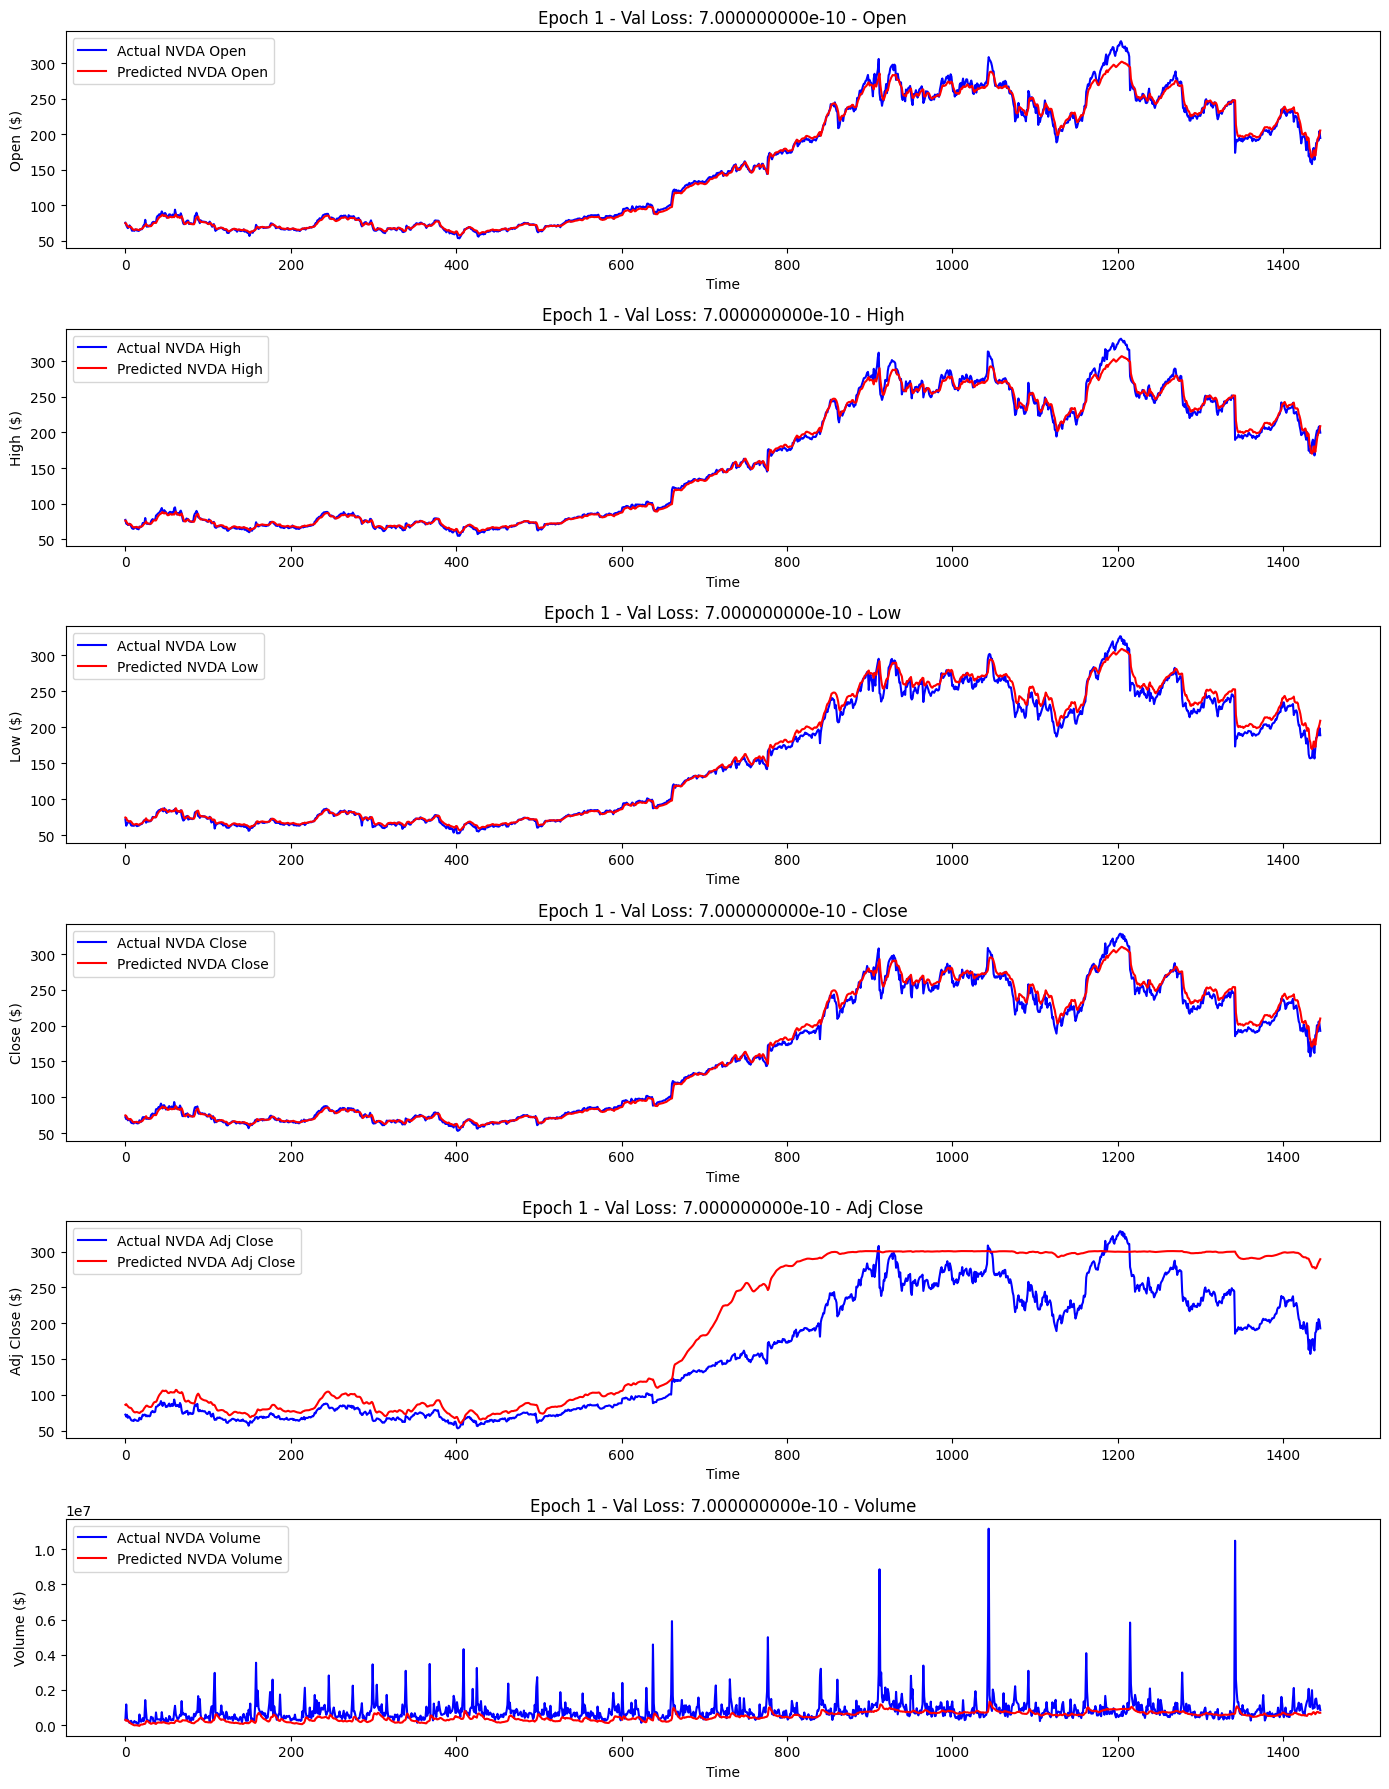

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

BEST_EPOCH = 1  # Update with the best epoch from training
BEST_VAL_LOSS = 7e-10  # Update with the best validation loss from

# --- Define the Model Architecture ---
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        # First LSTM layer: return sequences
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=256, num_layers=1, batch_first=True)
        self.dropout1 = nn.Dropout(0.3)
        # Second LSTM layer: return only final output (last timestep)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, num_layers=1, batch_first=True)
        self.dropout2 = nn.Dropout(0.3)
        # Dense output layer: same number of units as the number of features
        self.fc = nn.Linear(256, output_size)
        
    def forward(self, x):
        # x shape: (batch_size, look_back, input_size)
        out, _ = self.lstm1(x)           # out shape: (batch_size, look_back, 150)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)         # out shape: (batch_size, look_back, 150)
        # Take the output from the final timestep
        out = out[:, -1, :]              # shape: (batch_size, 150)
        out = self.dropout2(out)
        out = self.fc(out)               # shape: (batch_size, output_size)
        return out

# --- Data Loading and Preprocessing ---
# Load the NVDA CSV file (ensure the file path is correct)
nvda_df = pd.read_csv('./data/stocks/anet.csv')

# Convert the 'Date' column to datetime and set it as the index
nvda_df['Date'] = pd.to_datetime(nvda_df['Date'])
nvda_df.set_index('Date', inplace=True)

# Normalize the data using the scaler (assumed to be defined)
scaled_nvda = scaler.fit_transform(nvda_df)

# Check for NaN and infinity values
print("Checking for NaN values in data:", np.isnan(scaled_nvda).any())
print("Checking for infinity values in data:", np.isinf(scaled_nvda).any())

# Create dataset for NVDA using the provided create_dataset function (assumed to be defined)
X_nvda, y_nvda = create_dataset(scaled_nvda, look_back)

# Convert the input data to a PyTorch tensor
X_nvda_tensor = torch.from_numpy(X_nvda).float()

# --- Load the Trained Model from Best Epoch ---
input_size = nvda_df.shape[1]   # number of features
output_size = nvda_df.shape[1]    # same as input_size

model = LSTMModel(input_size=input_size, hidden_size=256, output_size=output_size)
model.load_state_dict(torch.load('7e-10.pth'))
model.eval()

# --- Make Predictions for NVDA ---
with torch.no_grad():
    predictions_tensor = model(X_nvda_tensor)
    
# Convert predictions to a NumPy array
nvda_predictions = predictions_tensor.numpy()

# --- Inverse Transform the Predictions and Actual Values ---
nvda_predictions_full = np.zeros_like(scaled_nvda)
nvda_actual_full = np.zeros_like(scaled_nvda)

nvda_predictions_full[look_back:look_back+len(nvda_predictions), -nvda_predictions.shape[1]:] = nvda_predictions
nvda_actual_full[look_back:look_back+len(y_nvda), -y_nvda.shape[1]:] = y_nvda

# Perform inverse transformation to get values in the original scale
nvda_predictions = scaler.inverse_transform(nvda_predictions_full)[look_back:look_back+len(nvda_predictions), -nvda_predictions.shape[1]:]
nvda_actual = scaler.inverse_transform(nvda_actual_full)[look_back:look_back+len(y_nvda), -y_nvda.shape[1]:]

# --- Plotting the Results ---
# Select a section of the time for display (modify the slice as needed)
time_section = slice(0, 30000)

# Get all feature names from the original DataFrame
features = nvda_df.columns.tolist()
n_features = len(features)

plt.figure(figsize=(14, 3 * n_features))
for i, feature in enumerate(features):
    plt.subplot(n_features, 1, i+1)
    plt.plot(nvda_actual[time_section, i], color='blue', label=f'Actual NVDA {feature}')
    plt.plot(nvda_predictions[time_section, i], color='red', label=f'Predicted NVDA {feature}')
    plt.title(f"Epoch {BEST_EPOCH} - Val Loss: {BEST_VAL_LOSS:.9e} - {feature}")
    plt.xlabel('Time')
    plt.ylabel(f'{feature} ($)')
    plt.legend()

plt.tight_layout()
plt.show()

In [16]:
import os
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

# Assumes you have already defined `model`, `LSTMModel`, and `look_back` above.

# 1) Ask for ticker and target date
symbol    = input("Enter ticker symbol (e.g. NVDA): ").upper()
date_str  = input("Enter target date (YYYY-MM-DD): ")
target_dt = pd.to_datetime(date_str)

# 2) Locate and load the CSV
data_dirs = ['./data/stocks', './data/etfs']
csv_path  = next((os.path.join(d, f"{symbol}.csv") for d in data_dirs
                  if os.path.exists(os.path.join(d, f"{symbol}.csv"))), None)
if csv_path is None:
    raise FileNotFoundError(f"Could not find {symbol}.csv in {data_dirs}")

df = pd.read_csv(csv_path, parse_dates=['Date']).set_index('Date')
features = df.columns.tolist()

# 3) Compute last historical date and days difference
last_dt   = df.index.max()
days_diff = (target_dt - last_dt).days

print(f"Last data point: {last_dt.date()}")
print(f"Target date   : {target_dt.date()}")
print(f"Days difference: {days_diff} day(s)")

# 4) Scale historical data
scaler_sym    = MinMaxScaler()
scaled_values = scaler_sym.fit_transform(df.values)

# 5) Load your trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load("7e-10.pth", map_location=device))
model.eval()

# 6) Build the sliding window and forecast
if days_diff <= 0:
    # In‑sample: single‑step using the window ending at target_dt
    if target_dt not in df.index:
        raise ValueError(f"{date_str} is not in the historical data for {symbol}.")
    idx    = df.index.get_loc(target_dt)
    if idx < look_back:
        raise ValueError(f"Need at least {look_back} prior days to predict.")
    window = scaled_values[idx - look_back : idx]
else:
    # Out‑of‑sample: iterate forward calendar‑day by calendar‑day
    window = scaled_values[-look_back:].copy()
    for _ in range(days_diff):
        x = torch.from_numpy(window[np.newaxis]).float().to(device)
        with torch.no_grad():
            out_scaled = model(x).cpu().numpy()[0]
        window = np.vstack([window[1:], out_scaled])

# 7) If in‑sample, run one more forward pass
if days_diff <= 0:
    x = torch.from_numpy(window[np.newaxis]).float().to(device)
    with torch.no_grad():
        out_scaled = model(x).cpu().numpy()[0]

# 8) Inverse‑scale and wrap into a Series
pred_orig = scaler_sym.inverse_transform(out_scaled.reshape(1, -1))[0]
pred      = pd.Series(pred_orig, index=features)

# 9) Print only the five fields you care about
print(f"\n📈 {symbol} forecast for {target_dt.date()}:")
for col in ["Open", "Close", "Volume", "High", "Low"]:
    if col in pred:
        print(f" • {col:6s}: {pred[col]:.2f}")
    else:
        print(f" ⚠️ Column '{col}' not found in data.")

Last data point: 2020-04-01
Target date   : 2023-03-12
Days difference: 1075 day(s)

📈 ANET forecast for 2023-03-12:
 • Open  : 255.33
 • Close : 261.83
 • Volume: 677534.19
 • High  : 259.37
 • Low   : 260.76
